In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
apps = pd.read_csv("apps.csv")
reviews = pd.read_csv("user_reviews.csv")

print(apps.head())
print(apps.shape)
print(apps.columns)

print(reviews.head())
print(reviews.shape)
print(reviews.columns)

   Unnamed: 0                                                App  \
0           0     Photo Editor & Candy Camera & Grid & ScrapBook   
1           1                                Coloring book moana   
2           2  U Launcher Lite – FREE Live Cool Themes, Hide ...   
3           3                              Sketch - Draw & Paint   
4           4              Pixel Draw - Number Art Coloring Book   

         Category  Rating  Reviews  Size     Installs  Type Price  \
0  ART_AND_DESIGN     4.1      159  19.0      10,000+  Free     0   
1  ART_AND_DESIGN     3.9      967  14.0     500,000+  Free     0   
2  ART_AND_DESIGN     4.7    87510   8.7   5,000,000+  Free     0   
3  ART_AND_DESIGN     4.5   215644  25.0  50,000,000+  Free     0   
4  ART_AND_DESIGN     4.3      967   2.8     100,000+  Free     0   

  Content Rating                     Genres      Last Updated  \
0       Everyone               Art & Design   January 7, 2018   
1       Everyone  Art & Design;Pretend Play  J

In [3]:
# Drop useless index-like column if present
if 'Unnamed: 0' in apps.columns:
    apps.drop('Unnamed: 0', axis=1, inplace=True)

# Remove duplicates
apps.drop_duplicates(inplace=True)

# Clean Installs column
apps['Installs'] = apps['Installs'].astype(str).str.replace(',', '', regex=False).str.replace('+', '', regex=False)
apps['Installs'] = pd.to_numeric(apps['Installs'], errors='coerce')

# Clean Price column
apps['Price'] = apps['Price'].astype(str).str.replace('$', '', regex=False)
apps['Price'] = pd.to_numeric(apps['Price'], errors='coerce')

# Convert Reviews to numeric
apps['Reviews'] = pd.to_numeric(apps['Reviews'], errors='coerce')

# Convert Rating to numeric
apps['Rating'] = pd.to_numeric(apps['Rating'], errors='coerce')

# Remove missing important values
apps = apps.dropna(subset=['App', 'Category', 'Rating', 'Installs', 'Type'])

print(apps.info())
print(apps.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 8196 entries, 0 to 9658
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             8196 non-null   object 
 1   Category        8196 non-null   object 
 2   Rating          8196 non-null   float64
 3   Reviews         8196 non-null   int64  
 4   Size            7027 non-null   float64
 5   Installs        8196 non-null   int64  
 6   Type            8196 non-null   object 
 7   Price           8196 non-null   float64
 8   Content Rating  8196 non-null   object 
 9   Genres          8196 non-null   object 
 10  Last Updated    8196 non-null   object 
 11  Current Ver     8192 non-null   object 
 12  Android Ver     8194 non-null   object 
dtypes: float64(3), int64(2), object(8)
memory usage: 896.4+ KB
None
App                  0
Category             0
Rating               0
Reviews              0
Size              1169
Installs             0
Type            

In [4]:
print(apps['Category'].value_counts().head(10))
print(apps['Type'].value_counts())
print(apps['Content Rating'].value_counts())

Category
FAMILY             1608
GAME                912
TOOLS               718
FINANCE             302
PRODUCTIVITY        301
LIFESTYLE           301
PERSONALIZATION     298
MEDICAL             290
BUSINESS            263
PHOTOGRAPHY         263
Name: count, dtype: int64
Type
Free    7592
Paid     604
Name: count, dtype: int64
Content Rating
Everyone           6618
Teen                912
Mature 17+          357
Everyone 10+        305
Adults only 18+       3
Unrated               1
Name: count, dtype: int64


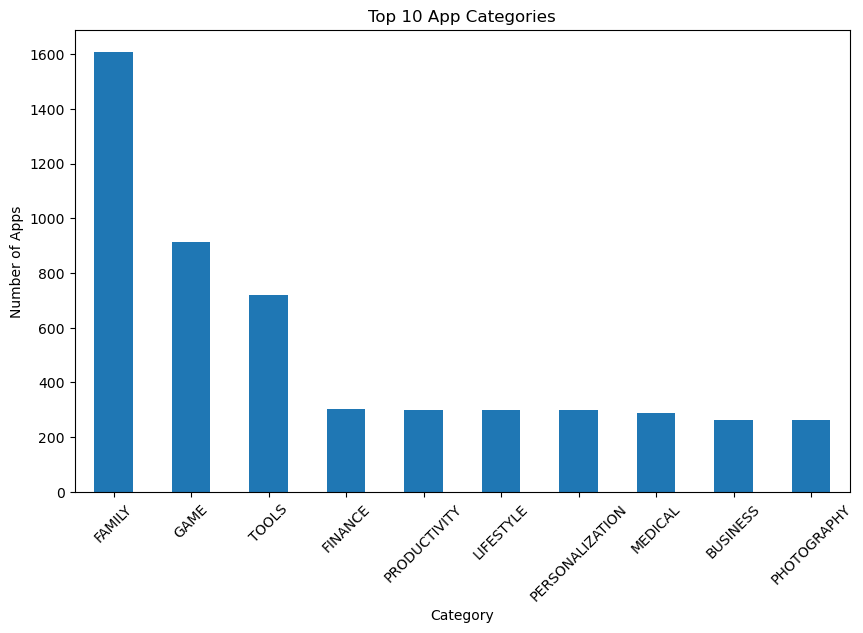

In [5]:
plt.figure(figsize=(10,6))
apps['Category'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 App Categories")
plt.xlabel("Category")
plt.ylabel("Number of Apps")
plt.xticks(rotation=45)
plt.show()

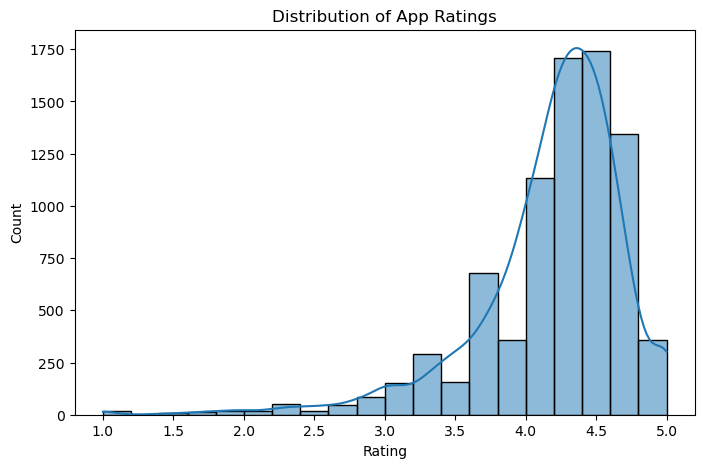

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(apps['Rating'], bins=20, kde=True)
plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

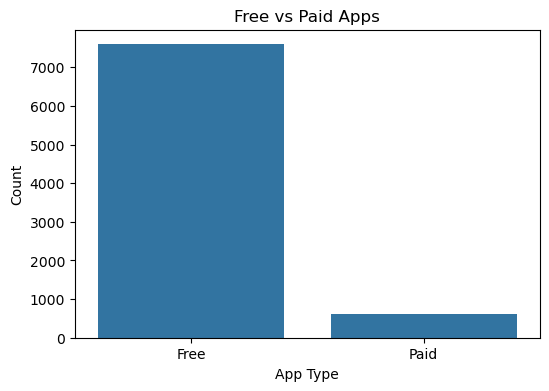

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='Type', data=apps)
plt.title("Free vs Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Count")
plt.show()

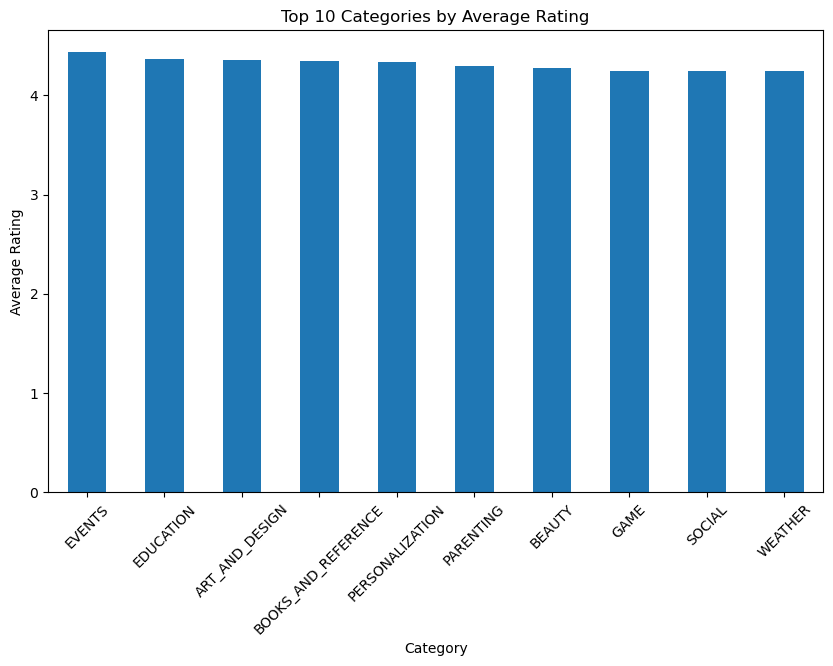

In [8]:
avg_rating = apps.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
avg_rating.plot(kind='bar')
plt.title("Top 10 Categories by Average Rating")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

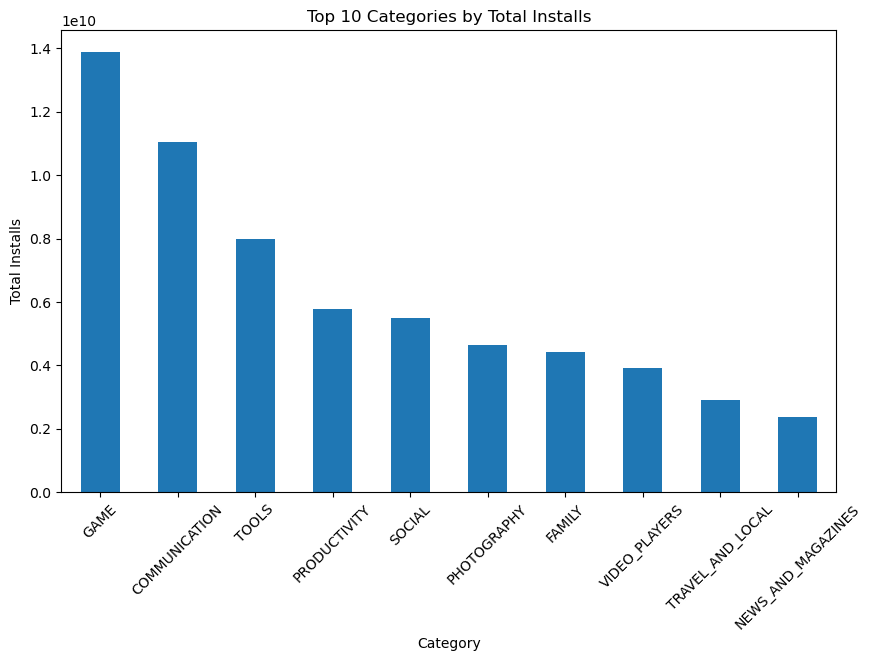

In [9]:
category_installs = apps.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
category_installs.plot(kind='bar')
plt.title("Top 10 Categories by Total Installs")
plt.xlabel("Category")
plt.ylabel("Total Installs")
plt.xticks(rotation=45)
plt.show()

In [10]:
reviews.drop_duplicates(inplace=True)
reviews = reviews.dropna(subset=['App', 'Sentiment'])

print(reviews.info())
print(reviews['Sentiment'].value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 29697 entries, 0 to 64230
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     29697 non-null  object 
 1   Translated_Review       29692 non-null  object 
 2   Sentiment               29697 non-null  object 
 3   Sentiment_Polarity      29697 non-null  float64
 4   Sentiment_Subjectivity  29697 non-null  float64
dtypes: float64(2), object(3)
memory usage: 1.4+ MB
None
Sentiment
Positive    19015
Negative     6321
Neutral      4361
Name: count, dtype: int64


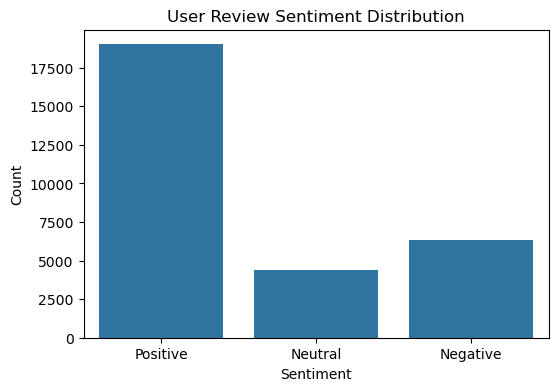

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sentiment', data=reviews)
plt.title("User Review Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

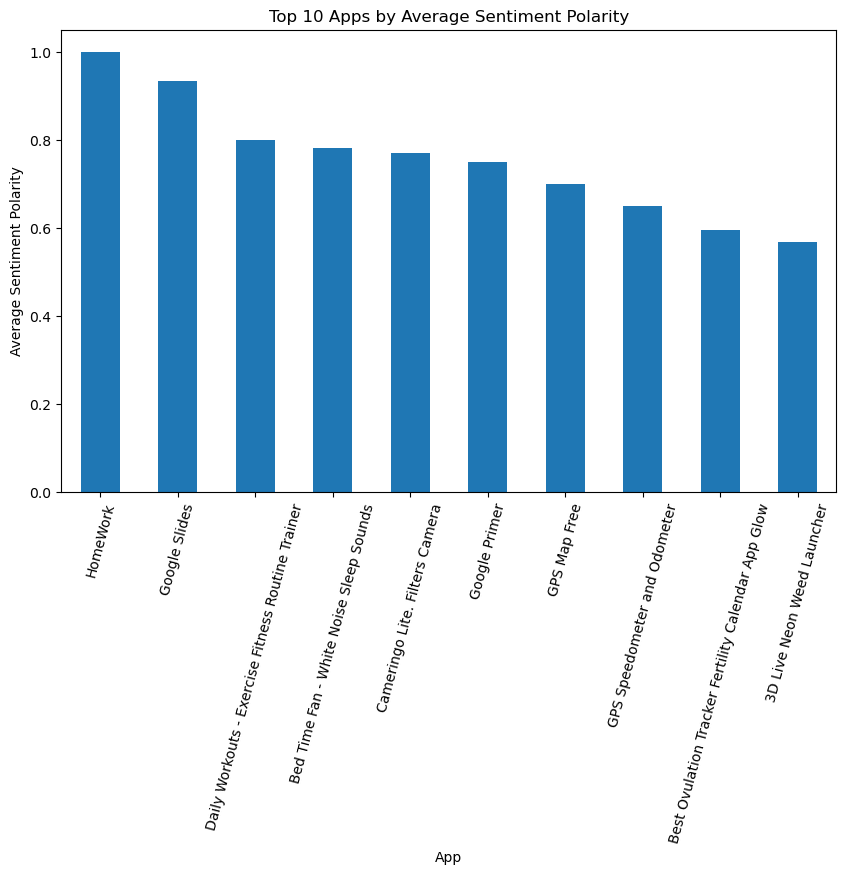

In [12]:
sentiment_by_app = reviews.groupby('App')['Sentiment_Polarity'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sentiment_by_app.plot(kind='bar')
plt.title("Top 10 Apps by Average Sentiment Polarity")
plt.xlabel("App")
plt.ylabel("Average Sentiment Polarity")
plt.xticks(rotation=75)
plt.show()

In [13]:
merged = pd.merge(apps, reviews, on='App', how='inner')
print(merged.head())
print(merged.shape)

                   App        Category  Rating  Reviews  Size  Installs  Type  \
0  Coloring book moana  ART_AND_DESIGN     3.9      967  14.0    500000  Free   
1  Coloring book moana  ART_AND_DESIGN     3.9      967  14.0    500000  Free   
2  Coloring book moana  ART_AND_DESIGN     3.9      967  14.0    500000  Free   
3  Coloring book moana  ART_AND_DESIGN     3.9      967  14.0    500000  Free   
4  Coloring book moana  ART_AND_DESIGN     3.9      967  14.0    500000  Free   

   Price Content Rating                     Genres      Last Updated  \
0    0.0       Everyone  Art & Design;Pretend Play  January 15, 2018   
1    0.0       Everyone  Art & Design;Pretend Play  January 15, 2018   
2    0.0       Everyone  Art & Design;Pretend Play  January 15, 2018   
3    0.0       Everyone  Art & Design;Pretend Play  January 15, 2018   
4    0.0       Everyone  Art & Design;Pretend Play  January 15, 2018   

  Current Ver   Android Ver  \
0       2.0.0  4.0.3 and up   
1       2.0.0  4.0

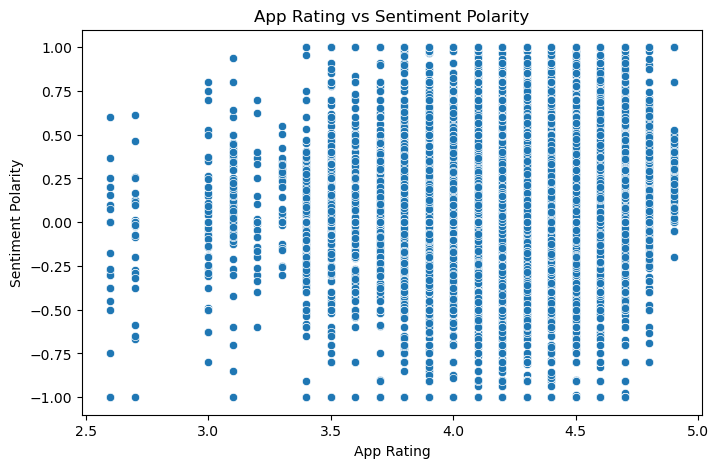

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Rating', y='Sentiment_Polarity', data=merged)
plt.title("App Rating vs Sentiment Polarity")
plt.xlabel("App Rating")
plt.ylabel("Sentiment Polarity")
plt.show()

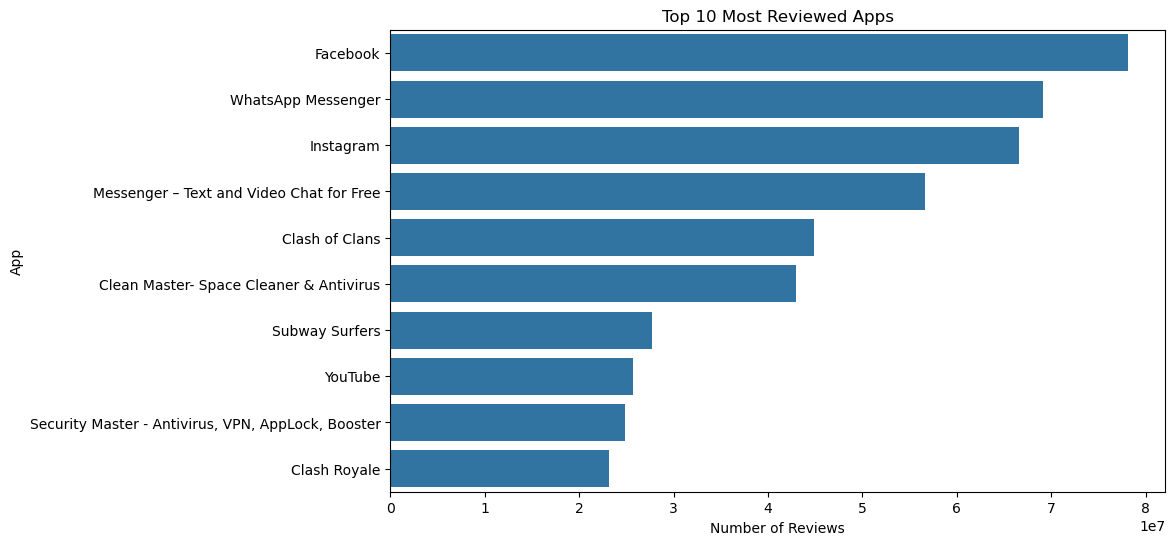

In [15]:
top_reviewed = apps.sort_values(by='Reviews', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='Reviews', y='App', data=top_reviewed)
plt.title("Top 10 Most Reviewed Apps")
plt.xlabel("Number of Reviews")
plt.ylabel("App")
plt.show()

In [16]:
print("Average App Rating:", apps['Rating'].mean())
print("Average App Price:", apps['Price'].mean())
print("Most Common App Category:", apps['Category'].mode()[0])
print("Most Common Sentiment:", reviews['Sentiment'].mode()[0])

Average App Rating: 4.173243045387993
Average App Price: 1.0378843338213763
Most Common App Category: FAMILY
Most Common Sentiment: Positive
